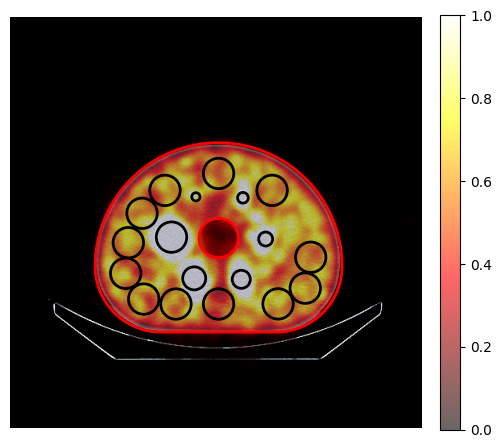

In [20]:
import tkinter as tk
from tkinter import ttk, filedialog, messagebox
from datetime import datetime
import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import pydicom
import os
from matplotlib.path import Path
import matplotlib.patches as patches

# -------------------- VARIABLES GLOBALES --------------------
# Estas variables almacenan imágenes, widgets y objetos compartidos entre
# los cálculos numéricos y la interfaz gráfica

archivos_ct = []      # Lista de archivos CT
archivo_spect = ""    # Archivo único SPECT

fig = None
ax = None
canvas = None

cbar = None        # Barra de colores asociada al SPECT
im_ct = None       # Objeto de imagen de Matplotlib para CT
im_spect = None    # Objeto de imagen de Matplotlib para SPECT

num_slices_ct = 1    # Numero de cortes de la imagen CT
num_slices_spect = 1 # Numero de cortes de la imagen SPECT

ct_img_sitk = None       # Imagen ct leída con SimplelTK 
spect_img_sitk = None    # Imagen spect leída con SimplelTK
spect_on_ct_sitk = None  # Imagen spect ya resampleada al grid del CT

ct_np = None    # Versión de la imagen ct en un array de Numpy
spect_np = None # Versión de la imagen spect en un array de Numpy

phantom = None # Phantom digital
mostrar_phantom = None

estado_var = None
label_estado = None

# --------------------- CLASES --------------------

class Phantom2D:
    """Representa la geometría del phantom y las ROIs usadas en el análisis."""
    def __init__(self):
        self.centro = np.array([0.0, 0.0]) # Coordenadas del centro del phantom en píxeles
        self.centro_base = None # Para almacenar el centro original como referencia en transformaciones

        self.radio_insertos_mm = 114.4 / 2 # Distancia radial nominal de los insertos al centro del phantom.
        self.diametros_mm = np.array([37, 10, 13, 17, 22, 28], dtype=float) # Diámetros físicos de las esferas calientes.

        self.radio_insertos_px = None
        self.diametros_px = None

        self.angulos = np.array([0, 60, 120, 180, 240, 300], dtype=float) # Ángulos de posición de las esferas calientes
        self.angulos_ini = self.angulos.copy() # Ángulos originales para referencia en rotaciones

    def obtener_info_equipo(self):
        """
        Extrae información del equipo y del tipo de imagen a partir
        de los metadatos DICOM del SPECT cargado.

        Returns:
            equipo: string con fabricante + modelo
            tipo: string con descripción de la serie (tipo de imagen)
        """
        try:
            # Tags DICOM
            fabricante = spect_img_sitk.GetMetaData("0008|0070")  # Fabricante del equipo (ej: GE, Siemens, Philips)
            modelo = spect_img_sitk.GetMetaData("0008|1090")      # Modelo del equipo (ej: Discovery NM/CT 640)
            descripcion = spect_img_sitk.GetMetaData("0008|103e") # Descripción de la serie (ej: IRAC, OSEM, NAC, etc.)

            # Combina fabricante y modelo en un solo texto
            equipo = f"{fabricante} {modelo}".strip()
            # Tipo de imagen/reconstrucción
            tipo = descripcion.strip()

            return equipo, tipo

        except:
            return "Equipo desconocido", "Tipo desconocido"

    def definir_centro_desde_imagen(self, imagen_np):
        """Sitúa el centro del phantom en el centro geométrico del volumen CT. "imagen_np" debe ser un array 3D [z, y, x]"""
        ny = imagen_np.shape[1]
        nx = imagen_np.shape[2]
        self.centro = np.array([nx/2, ny/2])

    def escalar_a_pixeles(self, spacing):
        """Convierte todos los parámetros geométricos de mm a píxeles. spacing = tamaño de pixel en mm"""
        self.radio_insertos_px = self.radio_insertos_mm / spacing
        self.diametros_px = self.diametros_mm / spacing

    def inicializar_desde_ct(self, ct_np, ct_img_sitk):
        """Inicializa centro y spacing del phantom a partir del CT cargado."""

        self.definir_centro_desde_imagen(ct_np)

        self.spacing = ct_img_sitk.GetSpacing()[0]
        self.escalar_a_pixeles(self.spacing)
        self.centro_base = self.centro.copy() # Guardamos el centro inicial como referencia para futuras transformaciones

    def transformar(self, angulo_deg, dx, dy):
        """Aplica una transformación respecto al estado base"""
        self.centro = self.centro_base + np.array([dx, dy])
        self.angulos = self.angulos_ini + angulo_deg

    def obtener_contorno(self, offset_mm=0, n=400):
        """
        Genera la curva cerrada que describe el contorno exterior del phantom.
        
        Parámetros:
        - offset_mm: desplazamiento en milímetros para contraer el contorno (útil para dibujar elementos dentro).
        - n: número total de puntos que describen la curva.
        """ 

        reduccion_px = offset_mm / self.spacing # Conversión del offset de mm a píxeles

        # Centro base del phantom
        cx = self.centro[0]
        cy = self.centro[1] + 35 # Desplazamiento vertical fijo

        # Radios principales (convertidos de mm a píxeles y ajustados por offset)
        radio_grande = (150 / self.spacing) - reduccion_px # arco superior
        radio_lat = (80 / self.spacing) - reduccion_px # laterales

        # 1. Arco superior (semicírculo)
        theta_gran = np.linspace(0, np.pi, n//4)
        x_gran = cx + radio_grande * np.cos(theta_gran)
        y_gran = cy - radio_grande * np.sin(theta_gran)

        # 2. Lateral izquierdo (cuarto de circunferencia)
        cx_l = cx - (70 / self.spacing)
        theta_l = np.linspace(np.pi, 1.5*np.pi, n//4)
        x_l = cx_l + radio_lat * np.cos(theta_l)
        y_l = cy - radio_lat * np.sin(theta_l)

        # 3. Base (línea recta)
        x_base = np.linspace(cx - (70 / self.spacing) + reduccion_px,
                    cx + (70 / self.spacing) - reduccion_px, n//4)
        y_base = np.full_like(x_base, cy + (80 / self.spacing) - reduccion_px)

        # 4. Lateral derecho (cuarto de circunferencia)
        cx_r = cx + (70 / self.spacing)
        theta_r = np.linspace(1.5*np.pi, 2*np.pi, n//4)
        x_r = cx_r + radio_lat * np.cos(theta_r)
        y_r = cy - radio_lat * np.sin(theta_r)

        # Unión de todos los segmentos
        x_total = np.concatenate([x_gran, x_l, x_base, x_r])
        y_total = np.concatenate([y_gran, y_l, y_base, y_r])

        return np.column_stack((x_total, y_total))
    
    def coordenadas_insertos(self):
        """
        Devuelve un array Nx2 con las coordenadas (x, y) de los insertos
        según la configuración actual del phantom.
        """
        coords = []
        for i, d in enumerate(self.diametros_px):
            ang_rad = np.deg2rad(self.angulos[i])
            # Calcular la posición del centro del inserto:
            # Se distribuyen sobre una circunferencia de radio fijo
            cx = self.centro[0] + self.radio_insertos_px * np.cos(ang_rad)
            cy = self.centro[1] + self.radio_insertos_px * np.sin(ang_rad)
            coords.append([cx, cy])

        # Convertir lista a array Nx2
        coords = np.array(coords)

        if reflejar.get():
            cx = self.centro[0]
            coords[:,0] = 2*cx - coords[:,0]

        return coords

    def coordenadas_background(self):
        """
        Devuelve un array Nx2 con las coordenadas (x, y)
        de las esferas de background (ROIs internas).
        """
        spacing = self.spacing
        offset_mm = 33 # Offset para evitar solapamiento con el contorno
        offset_px = offset_mm / spacing

        # Centro del phantom (ajustado en Y)
        cx = self.centro[0]
        cy = self.centro[1] + 35 / spacing

        # Radios de referencia (para posicionar puntos dentro del contorno)
        Rg = 150 - offset_px # arco superior
        Rl = 80 - offset_px  # laterales

        puntos = []

        # 1. Arco superior
        angulos_sup = [55, 90, 125, 145, 165]
        for ang in angulos_sup:
            theta = np.deg2rad(ang)
            x = cx + Rg * np.cos(theta)
            y = cy - Rg * np.sin(theta)
            puntos.append((x, y))

        # 2. Lateral izquierdo
        angulos_izq = [190, 240]
        for ang in angulos_izq:
            theta = np.deg2rad(ang)
            x = cx - 70 + Rl * np.cos(theta)
            y = cy - Rl * np.sin(theta)
            puntos.append((x, y))

        # 3. Base
        y_base = cy + 80 - offset_px
        puntos.append((cx, y_base))
        puntos.append((cx - 53, y_base))

        # 4. Lateral derecho
        angulos_der = [275, 325, 375]
        for ang in angulos_der:
            theta = np.deg2rad(ang)
            x = cx + 70 + Rl * np.cos(theta)
            y = cy - Rl * np.sin(theta)
            puntos.append((x, y))

        coords = np.array(puntos)

        if reflejar.get():
            cx = self.centro[0]
            coords[:,0] = 2*cx - coords[:,0]

        return coords
    
    def coordenadas_pulmon(self):
        """
        Devuelve el centro del inserto pulmonar en coordenadas del phantom.
        """
        # mismo sistema que el resto del phantom
        cx = self.centro[0]
        cy = self.centro[1]

        return np.array([[cx, cy]])

    def dibujar_contorno(self, ax, color="black", offset_mm=0):
        """
        Dibuja el contorno del phantom en un eje de matplotlib.

        Parámetros:
        - ax: eje de matplotlib donde se dibuja el contorno.
        - color: color de la línea del contorno.
        - offset_mm: desplazamiento en mm para contraer el contorno antes de dibujarlo.
        """
        # Obtener los puntos (x, y) del contorno
        contorno = self.obtener_contorno(offset_mm)

        # Asegurar que la curva esté cerrada repitiendo el primer punto al final
        vertices = np.vstack([contorno, contorno[0]])
        # Definir los códigos del Path:
        # - MOVETO: mueve al primer punto
        # - LINETO: dibuja líneas entre puntos consecutivos
        # - CLOSEPOLY: cierra la figura
        codes = [Path.MOVETO] + [Path.LINETO]*(len(vertices)-2) + [Path.CLOSEPOLY]

        # Crear el objeto Path con los vértices y sus instrucciones de dibujo
        path = Path(vertices, codes)
        patch = patches.PathPatch(path, fill=False, linewidth=2, color=color)

        # Añadir el contorno al eje
        ax.add_patch(patch)

    def dibujar_esferas_background(self, ax, color="black"):
        """
        Dibuja las ROIs circulares de background.
        """

        coords = self.coordenadas_background()

        r_roi_px = (37 / 2) / self.spacing

        for (x, y) in coords:
            ax.add_patch(
                plt.Circle(
                    (x, y),
                    r_roi_px,
                    fill=False,
                    linewidth=2,
                    color=color
                )
            )

    def dibujar_inserto_pulmon(self, ax, color="red"):

        coords = self.coordenadas_pulmon()

        diam_mm = 48
        radio_px = (diam_mm / 2) / self.spacing

        for (cx, cy) in coords:
            ax.add_patch(
                plt.Circle(
                    (cx, cy),
                    radio_px,
                    fill=False,
                    linewidth=2,
                    color=color
                )
            )            

    def dibujar(self, ax):
        """
        Dibuja el phantom completo:
        - Contorno exterior
        - Insertos circulares internos
        """

        # 1. Contorno exterior
        self.dibujar_contorno(ax, color="red", offset_mm=0)

        # 2. Insertos calientes
        if mostrar_hot.get():
            coords = self.coordenadas_insertos()
            radios = self.diametros_px / 2

            for i, (cx, cy) in enumerate(coords):
                ax.add_patch(
                    plt.Circle(
                        (cx, cy),
                        radios[i],
                        fill=False,
                        linewidth=2,
                        color="black"
                    )
                )

        # 3. Esferas de background
        if mostrar_background.get():
            coords_bg = self.coordenadas_background()

            r_bg_px = (37 / 2) / self.spacing

            for (x, y) in coords_bg:
                ax.add_patch(
                    plt.Circle(
                        (x, y),
                        r_bg_px,
                        fill=False,
                        linewidth=2,
                        color="black"
                    )
                )

        # 4. Inserto pulmón
        self.dibujar_inserto_pulmon(ax, color="red")


    def mask_phantom(self, shape):
        """
        Devuelve una máscara booleana del contorno del phantom.

        Parámetros:
        - shape: tupla (ny, nx) que indica el tamaño del slice 2D de la imagen.

        Returns:
        - mask: array booleano del mismo tamaño que la imagen,
                donde True indica píxeles que están dentro del contorno del phantom.
        """
        # 1. Obtener los puntos que definen el contorno del phantom (curva cerrada)
        contorno = self.obtener_contorno()

        # 2. Crear un objeto Path de matplotlib con el contorno
        #    Permite preguntar "este punto está dentro del contorno?"
        path = Path(contorno)

        # 3. Crear matrices con las coordenadas x e y de todos los píxeles
        y, x = np.indices(shape)

        # 4. Convertir la matriz de coordenadas en una lista de puntos N×2
        puntos = np.column_stack((x.ravel(), y.ravel()))

        # 5. Comprobar cuáles puntos están dentro del contorno
        mask = path.contains_points(puntos)

        # 6. Devolver la máscara con la forma original de la imagen
        return mask.reshape(shape)
    
    def slice_max_actividad(self, spect_array):
        """
        Devuelve el índice del slice del SPECT con mayor actividad
        total dentro del contorno del phantom.
        
        Parámetros:
        - spect_array: array 3D del SPECT [z, y, x]
        
        Returns:
        - Índice del slice con mayor actividad total
        """
        # 1. Crear una máscara booleana del phantom (True = píxeles dentro del contorno)
        mask = self.mask_phantom(spect_array[0].shape)

        # 2. Sumar la actividad de todos los píxeles dentro del phantom
        #    para cada slice a lo largo del eje z
        #    spect_array[:, mask] → selecciona todos los voxeles dentro del phantom
        #    np.sum(..., axis=1) → suma en el plano xy, queda un array 1D por slice
        actividad_total = np.sum(spect_array[:, mask], axis=1)

        # 3. Devolver el índice del slice con la máxima actividad total
        return np.argmax(actividad_total)


    def actividad_por_insertos_en_slice(self, spect_array, slice_max, x, y):
        """
        Calcula la actividad media en cada inserto
        para el slice con mayor actividad total.
        """
        if spect_array is None:
            messagebox.showwarning("Atención", "No hay datos SPECT cargados")
            return
        
        coords = self.coordenadas_insertos()
        radios = self.diametros_px / 2

        actividad_list = [] # Lista para almacenar la actividad de cada inserto en este slice
        for i, r in enumerate(radios): # Recorre cada inserto definido en el phantom, usando los radios pre-calculados
            cx, cy = coords[i] # Coordenadas del centro del inserto i-ésimo, pre-calculadas
            mask = mask_circulo_area(x, y, cx, cy, r) # Máscara booleana que es True para los píxeles dentro del círculo del inserto
            actividad_list.append(np.mean(spect_array[slice_max][mask])) # Suma de la actividad de los píxeles dentro del inserto i-ésimo en el slice con mayor actividad total

        # Para imprimir en pantalla:

        # Crear lista de tuplas (diametro, actividad, indice)
        datos_insertos = [(self.diametros_mm[i], actividad_list[i], i) for i in range(len(self.diametros_mm))]
        # Ordenar por diámetro
        datos_insertos.sort(key=lambda x: x[0])

        # Mostrar en el widget de texto
        resumen = f"Slice con mayor actividad: {slice_max}\n\n"
        for diam, act, idx in datos_insertos:
            diam_mm = self.diametros_mm[idx]
            # Volumen (aproximación cilíndrica: área * espesor)
            volumen = np.pi*(diam_mm/2)**2 * spect_img_sitk.GetSpacing()[2]
            resumen += f"Esfera Diámetro {diam:.2f} mm → {(act/volumen):.2f} act/vol\n"

        return np.array(actividad_list)

    def actividad_background_en_slice(self, spect_array, slice_max, x, y):
        """
        Calcula la actividad media en las ROIs de background
        en el slice de máxima actividad.
        """
        if spect_array is None:
            messagebox.showwarning("Atención", "No hay datos SPECT cargados")
            return

        coords_bg = self.coordenadas_background()
        r_bg = (37 / 2) # Radio igual al inserto grande (37 mm)
        r_bg_px = r_bg/self.spacing

        actividad_bg = []

        # Calcular actividad en cada ROI
        for cx, cy in coords_bg:
            mask = mask_circulo_area(x, y, cx, cy, r_bg_px)
            actividad_bg.append(np.mean(spect_array[slice_max][mask]))

        # Mostrar resultados
        resumen = f"\nActividad background (slice {slice_max}):\n\n"

        for i, act in enumerate(actividad_bg):
            volumen = np.pi*(r_bg)**2 * spect_img_sitk.GetSpacing()[2] # Volumen de la esfera de fondo en mm³, calculado como área del círculo (pi*r^2) por el espesor del slice (spacing en Z)
            resumen += f"ROI BG {i+1}: {act:.2f} px → {(act/volumen):.2f} act/vol\n"

        return np.array(actividad_bg)
    
    def calcular_Q(self, spect_array, slice_max, a_H, a_B): # Función independiente de la interfaz
        """
        Calcula los Percent Contrast (Q) de los insertos para un slice dado.
        Q = ((media de la actividad_insertos / media de la actividad_bg) - 1) / ((a_H / a_B) - 1) * 100
        
        Args:
            spect_array: array 3D con la imagen SPECT [z,y,x]
            slice_max: índice del slice a analizar
            a_H: actividad específica de las esferas calientes (act_hot/vol_hot)
            a_B: actividad específica de las esferas de background (act_bg/vol_bg)
        
        Returns:
            Q: array con Q (%) de cada inserto
        """
        y, x = np.indices(spect_array[slice_max].shape)

        if spect_array is None:
            messagebox.showwarning("Atención", "No hay datos SPECT")
            return

        coords = self.coordenadas_insertos()
        radios = self.diametros_mm / 2
        radios_px = radios / self.spacing
        
        actividad_insertos = np.array([
            np.mean(spect_array[slice_max][mask_circulo_area(x, y, cx, cy, r)])
            for (cx, cy), r in zip(coords, radios_px)])

        # Actividad de background
        coords_bg = self.coordenadas_background()
        r_bg_mm = 37 / 2  # mm
        r_bg_px = r_bg_mm / self.spacing

        actividad_bg = np.array([
            np.mean(spect_array[slice_max][mask_circulo_area(x, y, cx, cy, r_bg_px)])
            for cx, cy in coords_bg])
        
        # Q en %
        Q = ((actividad_insertos / np.mean(actividad_bg)) - 1) / ((a_H / a_B) - 1) * 100

        return Q

    def calcular_RC(self, spect_array, slice_max, a_H, a_B):
        """
        Calcula el Recovery Coefficient (RC) a partir del Q ya calculado.
        RC = Q (1 - 1/R) + 1/R

        Args:
            spect_array: array 3D SPECT
            a_H: actividad específica esferas calientes
            a_B: actividad específica background
            R: ratio actividad hot/background (a_H / a_B)

        Returns:
            RC: array con RC de cada inserto
        """

        if spect_array is None:
            messagebox.showwarning("Atención", "No hay datos SPECT")
            return None

        R = a_H/a_B

        # Calcular Q
        Q = self.calcular_Q(spect_array, slice_max, a_H, a_B)

        if Q is None:
            return None
        
        # Fórmula RC
        RC = Q * (1 - 1/R) + (1/R)

        return RC
    

    def incertidumbre_voxel(self, spect_array, a_H, a_B): # Función independiente de la interfaz
        """
        Calcula los valores nominales de Q y RC, junto con sus incertidumbres absolutas,
        evaluando la sensibilidad a pequeños desplazamientos del phantom (±0.5 píxeles).

        Args:
            spect_array: array 3D del SPECT
            a_H: actividad específica de las esferas calientes
            a_B: actividad específica del background

        Returns:
            Q_nominal: valores de Q en la posición central (sin desplazamiento)
            sigma_abs_Q: incertidumbre absoluta (desviación estándar) de Q
            RC_nominal: valores de RC en la posición central
            sigma_abs_RC: incertidumbre absoluta de RC
        """

        slice_max = self.slice_max_actividad(spect_array)
        centro_original = self.centro.copy()

        # Desplazamientos de ±0.5 píxel
        # Se evalúan 9 posiciones: una malla 3x3 alrededor del centro
        shifts = [
            (-0.5,-0.5),(0,-0.5),(0.5,-0.5),
            (-0.5,0),(0,0),(0.5,0),
            (-0.5,0.5),(0,0.5),(0.5,0.5)
        ]

        Q_list = []
        RC_list = []

        # Evaluar cada desplazamiento
        for dx, dy in shifts:
            # Desplazar el centro del phantom
            self.centro = centro_original + np.array([dx, dy])
             # Calcular métricas en esta posición
            Q = self.calcular_Q(spect_array, slice_max, a_H, a_B)
            RC = self.calcular_RC(spect_array, slice_max, a_H, a_B)
            if Q is not None and RC is not None:
                Q_list.append(Q)
                RC_list.append(RC)

        self.centro = centro_original # restaurar centro original
        Q_array = np.array(Q_list) # shape (9, num_insertos)
        RC_array =  np.array(RC_list) # shape (9, num_insertos)  

        Q_nominal = Q_array[4]  # posición central (0,0)
        RC_nominal = RC_array[4]  # posición central (0,0)

        sigma_abs_Q = np.std(Q_array, axis=0, ddof=1) # absoluta de Q
        sigma_abs_RC = np.std(RC_array, axis=0, ddof=1) # absoluta de RC
        # ddof=1 → estimador insesgado (muestra)

        return Q_nominal, sigma_abs_Q, RC_nominal, sigma_abs_RC
    
    def incertidumbre_estadistica(self, spect_array, a_H, a_B):
        """
        Calcula la incertidumbre estadística de Q y RC debida únicamente
        a la variabilidad en las ROIs de background.

        Args:
            spect_array: array 3D SPECT
            a_H: actividad específica de esferas calientes
            a_B: actividad específica de background
        
        Returns:
            sigma_stat_Q: incertidumbre estadística de Q para cada inserto
            sigma_stat_RC: incertidumbre estadística de RC para cada inserto
        """
        slice_max = self.slice_max_actividad(spect_array)
        y, x = np.indices(spect_array[slice_max].shape)

        # Obtener actividad medida
        actividad_insertos = self.actividad_por_insertos_en_slice(spect_array, slice_max, x, y)
        actividad_bg = self.actividad_background_en_slice(spect_array, slice_max, x, y)

        # Estadísticos del background
        mean_bg = np.mean(actividad_bg)
        sd_bg = np.std(actividad_bg, ddof=1)
        sigma_bg = sd_bg / np.sqrt(len(actividad_bg))

        L = 100 / ((a_H / a_B) - 1) # Constante

        # Incertidumbre estadística de Q debida al background
        sigma_stat_Q = L * (actividad_insertos / mean_bg**2) * sigma_bg

        # Incertidumbre estadística de RC (propagación lineal desde Q hacia RC)
        R = a_H / a_B
        sigma_stat_RC = sigma_stat_Q * abs(1 - 1/R)

        return sigma_stat_Q, sigma_stat_RC

    def plot_Q_and_RC(self, spect_array):
        """
        Genera las curvas de calibración Q y RC (2D y 3D),
        incluyendo incertidumbres geométricas y estadísticas,
        y las muestra en una ventana con gráficos y tablas.
        """
        # 1. Leer inputs de la interfaz
        try:
            act_hot = float(entry_actividad_hot.get())
            vol_hot = float(entry_volumen_hot.get())
            act_bg  = float(entry_actividad_bg.get())
            vol_bg  = float(entry_volumen_bg.get())
        except:
            messagebox.showerror("Error", "Introduce actividades y volúmenes")
            return

        # Actividades específicas (act/vol)
        a_H = act_hot / vol_hot
        a_B = act_bg  / vol_bg

        # 2. Obtener Q y RC + incertidumbre geométrica (absolutas)
        Q, sigma_abs_Q, RC, sigma_abs_RC = self.incertidumbre_voxel(spect_array, a_H, a_B)
        if Q is None or RC is None:
            return
        
        # 3. Obtener incertidumbre estadística
        sigma_stat_Q, sigma_stat_RC = self.incertidumbre_estadistica(spect_array, a_H, a_B)

        # 4. Ordenar por diámetro
        diam = self.diametros_mm
        # Convertir a volumen (mL)
        vol = (4/3) * np.pi * (diam/2)**3 / 1000  # Dividir por 1000 para convertir de mm³ a mL
        orden = np.argsort(vol)
        vol = vol[orden]

        Q = Q[orden]
        sigma_abs_Q = sigma_abs_Q[orden]
        sigma_stat_Q = sigma_stat_Q[orden]

        RC = RC[orden]
        sigma_abs_RC = sigma_abs_RC[orden]
        sigma_stat_RC = sigma_stat_RC[orden]

        # 5. Transformación volumétrica (3D)
        # Q^(3/2): corrección por volumen (efecto parcial)

        Q_32 = (Q/100)**(3/2) * 100 # Divido por 100 para normalizar, elevo a 3/2, y multiplico por 100 para volver a porcentaje
        sigma_abs_Q_32 = ((Q + sigma_abs_Q)/100)**(3/2) * 100 - Q_32 # Aplico la transformación volumétrica y resto el valor nominal.
        sigma_stat_Q_32 = (3/2) * np.sqrt(Q/100) * sigma_stat_Q # Derivada del Q elevado a 3/2 respecto al Q, multiplicada por la incertidumbre estadística del Q para propagarla al Q^(3/2)

        RC_32 = (RC/100)**(3/2) * 100
        sigma_abs_RC_32 = ((RC + sigma_abs_RC)/100)**(3/2) * 100 - RC_32
        sigma_stat_RC_32 = (3/2) * np.sqrt(RC/100) * sigma_stat_RC

        # 6. Crear ventana de resultados
        ventana = tk.Toplevel()
        equipo, tipo_imagen = self.obtener_info_equipo()
        ventana.title(f"Curvas de calibración → {equipo} | {tipo_imagen}")
        ventana.geometry("1200x650")

        frame = ttk.Frame(ventana)
        frame.pack(fill="both", expand=True)

        # 7. Curvas 2D
        frame_Q2d = ttk.Frame(frame)
        frame_Q2d.pack(side="left", fill="both", expand=True, padx=5, pady=5)

        # Incertidumbre total (geométrica + estadística)
        sigma_total_Q = np.sqrt(sigma_abs_Q**2 + sigma_stat_Q**2)  # incertidumbre total
        sigma_total_RC = np.sqrt(sigma_abs_RC**2 + sigma_stat_RC**2)

        fig1 = plt.Figure(figsize=(5,4))
        ax1 = fig1.add_subplot(111)

        ax1.errorbar(vol, Q, yerr=sigma_total_Q, fmt='o', markersize=4, ecolor = 'black', capsize = 4, label='Q (%)')
        ax1.errorbar(vol, RC, yerr=sigma_total_RC, fmt = 's', markersize=4, ecolor = 'black', capsize = 4, label='RC (%)')
        
        ax1.set_xlabel("Volumen esfera (mL)")
        ax1.set_ylabel("%")
        ax1.set_title("Curvas de calibración (2D)")
        ax1.set_ylim(0,100)
        ax1.legend()
        ax1.grid()

        # Mostrar gráfico en Tkinter
        canvas1 = FigureCanvasTkAgg(fig1, master=frame_Q2d)
        canvas1.draw()
        canvas1.get_tk_widget().pack(side="top", fill="both", expand=True)

        # 8. Tabla 2D
        frame_table1 = ttk.Frame(frame_Q2d)
        frame_table1.pack(side="top", fill="x", pady=5)
        tabla1 = ttk.Treeview(frame_table1, columns=("Diam", "Q ± σ_sis", "Q ± σ_stat", "RC ± σ_sis", "RC ± σ_stat"), show="headings", height=len(diam))
        
        # Encabezados
        tabla1.heading("Diam", text="Vol (mL)")
        tabla1.heading("Q ± σ_sis", text="Q ± σ_sis")
        tabla1.heading("Q ± σ_stat", text="Q ± σ_stat")
        tabla1.heading("RC ± σ_sis", text="RC ± σ_sis")
        tabla1.heading("RC ± σ_stat", text="RC ± σ_stat")

        tabla1.column("Diam", width=60, anchor="center")
        tabla1.column("Q ± σ_sis", width=100, anchor="center")
        tabla1.column("Q ± σ_stat", width=100, anchor="center")
        tabla1.column("RC ± σ_sis", width=100, anchor="center")
        tabla1.column("RC ± σ_stat", width=100, anchor="center")

         # Rellenar tabla
        for v, q, s_sys_Q, s_stat_Q, rc, s_sys_RC, s_stat_RC in zip(vol, Q, sigma_abs_Q, sigma_stat_Q, RC, sigma_abs_RC, sigma_stat_RC):
            tabla1.insert("", tk.END,
                values=(f"{v:.0f}", f"{q:.1f} ± {s_sys_Q:.1f}", f"{q:.1f} ± {s_stat_Q:.1f}", f"{rc:.1f} ± {s_sys_RC:.1f}", f"{rc:.1f} ± {s_stat_RC:.1f}"))
        
        tabla1.pack(fill="x")

        # 9. Curvas 3D (Q^(3/2))
        frame_Q32 = ttk.Frame(frame)
        frame_Q32.pack(side="left", fill="both", expand=True, padx=5, pady=5)

        sigma_total_Q_32 = np.sqrt(sigma_abs_Q_32**2 + sigma_stat_Q_32**2)
        sigma_total_RC_32 = np.sqrt(sigma_abs_RC_32**2 + sigma_stat_RC_32**2)

        fig2 = plt.Figure(figsize=(5,4))
        ax2 = fig2.add_subplot(111)
        
        ax2.errorbar(vol, Q_32, yerr=sigma_total_Q_32, fmt='o', markersize=4, ecolor = 'black', capsize = 4, label='Q (%)')
        ax2.errorbar(vol, RC_32, yerr=sigma_total_RC_32, fmt='s', markersize=4, ecolor = 'black', capsize = 4, label='RC (%)')
        
        ax2.set_xlabel("Volumen esfera (mL)")
        ax2.set_ylabel("%")
        ax2.set_title("Curvas de calibración (3D)")
        ax2.set_ylim(0,100)
        ax2.legend()
        ax2.grid()

        canvas2 = FigureCanvasTkAgg(fig2, master=frame_Q32)
        canvas2.draw()
        canvas2.get_tk_widget().pack(side="top", fill="both", expand=True)

        # 10. Tabla 3D
        frame_table2 = ttk.Frame(frame_Q32)
        frame_table2.pack(side="top", fill="x", pady=5)
        
        tabla2 = ttk.Treeview(frame_table2, columns=("Diam", "Q ± σ_sis", "Q ± σ_stat", "RC ± σ_sis", "RC ± σ_stat"), show="headings", height=len(diam))
        
        tabla2.heading("Diam", text="Vol (mL)")
        tabla2.heading("Q ± σ_sis", text="Q ± σ_sis")
        tabla2.heading("Q ± σ_stat", text="Q ± σ_stat")
        tabla2.heading("RC ± σ_sis", text="RC ± σ_sis")
        tabla2.heading("RC ± σ_stat", text="RC ± σ_stat")

        tabla2.column("Diam", width=60, anchor="center")
        tabla2.column("Q ± σ_sis", width=120, anchor="center")
        tabla2.column("Q ± σ_stat", width=120, anchor="center")
        tabla2.column("RC ± σ_sis", width=120, anchor="center")
        tabla2.column("RC ± σ_stat", width=120, anchor="center")
        
        for v, q32, s_sys_Q, s_stat_Q, rc32, s_sys_RC, s_stat_RC in zip(vol, Q_32, sigma_abs_Q_32, sigma_stat_Q_32, RC_32, sigma_abs_RC_32, sigma_stat_RC_32):
            tabla2.insert("", tk.END, values=(f"{v:.0f}", f"{q32:.1f} ± {s_sys_Q:.1f}", f"{q32:.1f} ± {s_stat_Q:.1f}", f"{rc32:.1f} ± {s_sys_RC:.1f}", f"{rc32:.1f} ± {s_stat_RC:.1f}"))

        tabla2.pack(fill="x")


        # -------- BOTÓN DE GUARDADO --------
        def guardar_resultados():
            """
            Guarda los resultados generados:
            - Gráficas (2D y 3D) en formato PNG
            - Valores numéricos en CSV

            El usuario elige el nombre base del archivo.
            """
            # 1. Selección de ruta
            ruta_base = filedialog.asksaveasfilename(
                title="Guardar resultados",
                defaultextension=".csv",
                filetypes=[("Archivo CSV", "*.csv")],
                initialfile="resultados"
            )
            if not ruta_base:
                return

            # 2. Construir rutas de salida
            carpeta = os.path.dirname(ruta_base)
            nombre_base = os.path.splitext(os.path.basename(ruta_base))[0]
            # Archivos de salida
            png_q2d = os.path.join(carpeta, f"{nombre_base}_gráfica_2D.png")
            png_q3d = os.path.join(carpeta, f"{nombre_base}_gráfica_3D.png")
            csv_path = os.path.join(carpeta, f"{nombre_base}_valores.csv")

            # 3. Guardar gráficas
            fig1.savefig(png_q2d)
            fig2.savefig(png_q3d)

            import csv

            # Función para formatear números (coma decimal estilo europeo)
            def fmt(x):
                return f"{x:.5f}".replace(".", ",")

            with open(csv_path, mode="w", newline="", encoding="utf-8") as f:
                writer = csv.writer(f, delimiter=";")
                # Cabecera del CSV
                writer.writerow([
                    "Diametro (mm)",
                    "Q 2D (%)", "Sigma sistematica Q 2D", "Sigma estadistica Q 2D",
                    "RC 2D (%)", "Sigma sistematica RC 2D", "Sigma estadistica RC 2D",
                    "Q 3D (%)", "Sigma sistematica Q 3D", "Sigma estadistica Q 3D",
                    "RC 3D (%)", "Sigma sistematica RC 3D", "Sigma estadistica RC 3D"
                ])
                # Escribir datos fila a fila
                for d, q2d, s_sys, s_stat, rc2d, s_sys_rc, s_stat_rc, q3d, s3d_sys, s3d_stat, rc3d, s3d_sys_rc, s3d_stat_rc in zip(
                    diam, Q, sigma_abs_Q, sigma_stat_Q, RC, sigma_abs_RC, sigma_stat_RC,
                    Q_32, sigma_abs_Q_32, sigma_stat_Q_32, RC_32, sigma_abs_RC_32, sigma_stat_RC_32
                ):
                    writer.writerow([
                        fmt(d),
                        fmt(q2d), fmt(s_sys), fmt(s_stat),
                        fmt(rc2d), fmt(s_sys_rc), fmt(s_stat_rc),
                        fmt(q3d), fmt(s3d_sys), fmt(s3d_stat),
                        fmt(rc3d), fmt(s3d_sys_rc), fmt(s3d_stat_rc)
                    ])

            # 5. Confirmación al usuario
            messagebox.showinfo(
                "Guardado",
                f"Resultados guardados en:\n{carpeta}\n\n"
                f"{os.path.basename(png_q2d)}\n"
                f"{os.path.basename(png_q3d)}\n"
                f"{os.path.basename(csv_path)}"
            )

        # Botón en la interfaz
        ttk.Button(ventana, text="Guardar resultados", command=guardar_resultados).pack(side="bottom", pady=8)

# -------------------- FUNCIONES --------------------
# global --> los cambios que se hagan dentro de la función afectarán a estas variables fuera de la función

def mask_circulo_area(x, y, cx, cy, r):
    """
    Devuelve una máscara booleana que indica si los píxeles (x, y) 
    están dentro de un círculo definido por centro (cx, cy) y radio r,
    usando una aproximación de subpíxeles (3x3) para mayor precisión.

    Parámetros:
    - x, y: arrays con coordenadas de los píxeles.
    - cx, cy: coordenadas del centro del círculo.
    - r: radio del círculo.

    Returns:
    - mask: array booleano del mismo tamaño que x/y, True si el píxel
            está mayormente dentro del círculo.
    """
    # 1. Definir offsets para evaluar subpíxeles dentro de cada píxel
    #    Se crea una rejilla 3x3 centrada en el píxel
    offsets = [-0.33, 0.0, 0.33]

    # 2. Contador para llevar la cantidad de subpíxeles que caen dentro del círculo
    count = np.zeros_like(x, dtype=int)

    # 3. Iterar sobre todos los offsets en x y y (9 subpíxeles por píxel)
    for dx in offsets:
        for dy in offsets:
            # 3a. Comprobar si el subpíxel (x+dx, y+dy) está dentro del círculo
            inside = (x + dx - cx)**2 + (y + dy - cy)**2 <= r**2
            # 3b. Sumar al contador: True→1, False→0
            count += inside

    # 4. Si la mayoría de los subpíxeles (al menos 5 de 9) está dentro, 
    #    consideramos que el píxel entero está dentro del círculo
    return count >= 5


def seleccionar_ct():
    """
    Carga una serie DICOM de CT desde una carpeta y prepara la interfaz
    para visualizarla.

    Flujo:
    1. El usuario selecciona una carpeta con los ficheros DICOM del CT.
    2. Se reconstruye la serie completa con SimpleITK.
    3. La imagen se convierte a un array de NumPy para poder acceder a los slices.
    4. Se actualiza el slider del CT.
    5. Se inicializa el phantom digital usando la geometría del CT.
    6. Se actualiza la visualización.
    """
    global archivos_ct, ct_img_sitk, ct_np, num_slices_ct, phantom

    # Abrir un diálogo para que el usuario seleccione la carpeta del CT
    carpeta = filedialog.askdirectory(title="Seleccionar carpeta con cortes CT (.dcm)")
    if not carpeta:
        return
    
    mostrar_estado("Leyendo ficheros CT...")

    try:
        # Mostrar en la interfaz la ruta seleccionada
        archivos_ct = carpeta
        
        entry_ct.delete(0, tk.END)
        # Separar la ruta en partes
        partes = os.path.normpath(carpeta).split(os.sep)
        # Tomar las 3 últimas carpetas
        ultimas_tres = os.sep.join(partes[-3:])
        entry_ct.insert(0, ultimas_tres)

        # Leer la serie DICOM completa del CT
        # ImageSeriesReader identifica qué archivos pertenecen a una misma serie
        reader = sitk.ImageSeriesReader() # Crea un lector de imagenes DICOM de SimplelTK
        series_ids = reader.GetGDCMSeriesIDs(carpeta) # Obtiene los IDs de todas las series DICOM
        if not series_ids:
            messagebox.showerror("Error", "No se encontraron series DICOM en la carpeta seleccionada.")
            return

        file_names = reader.GetGDCMSeriesFileNames(carpeta, series_ids[0]) # obtiene los nombres
        reader.SetFileNames(file_names) 
        ct_img_sitk = reader.Execute()

        archivos_ct = file_names # Sobrescribe la variable archivos_ct con la lista de archivos individuales de la serie, en lugar de la ruta de la carpeta.

        # Convertir la imagen SimpleITK a array NumPy con forma [z, y, x]
        ct_np = sitk.GetArrayFromImage(ct_img_sitk)
        num_slices_ct = ct_np.shape[0] # Número de cortes axiales del CT

        # Configurar el slider del CT y colocarlo inicialmente en el corte central
        ct_slider.config(to=num_slices_ct - 1)
        slice_idx_ct.set(num_slices_ct // 2)

        # Inicializar figura
        if fig is None:
            inicializar_figura()

        # Crear el phantom digital y adaptarlo a la geometría del CT
        # El phantom usa el tamaño de píxel del CT para convertir mm a píxeles
        phantom = Phantom2D()
        phantom.inicializar_desde_ct(ct_np, ct_img_sitk)

        if spect_img_sitk is not None:
            mostrar_estado("Alineando SPECT con CT...")
            resamplear_spect_a_ct()

        # Redibujar la visualización con el nuevo CT cargado
        actualizar_overlay()
    
    finally:
        mostrar_estado("Fichero CT cargado correctamente.")
        root.after(3000, limpiar_estado)  # se borra en 3 segundos


def seleccionar_fichero_spect():
    """
    Carga un fichero DICOM SPECT y lo prepara para superponerlo al CT.

    Flujo:
    1. El usuario selecciona un fichero DICOM SPECT.
    2. Se extrae, si existe, la fecha de adquisición para mostrarla en la interfaz.
    3. Se carga la imagen SPECT con SimpleITK.
    4. Se convierte a NumPy.
    5. Se busca el slice de máxima actividad para posicionar el slider del SPECT.
    6. Si ya existe un CT cargado, el SPECT se reamuestra al plano XY del CT.
    7. Se actualiza la visualización.
    """
    global archivo_spect, spect_img_sitk, spect_np, num_slices_spect 

    # Abrir diálogo para seleccionar el fichero DICOM SPECT
    ruta = filedialog.askopenfilename(
        title="Seleccionar fichero SPECT",
        filetypes=[("Archivos DICOM", "*.dcm")]
    )
    if not ruta:
        return
    
    limpiar_estado()
    mostrar_estado("Leyendo fichero SPECT...")

    try:
        # Guardar y mostrar la ruta seleccionada en la interfaz
        archivo_spect = ruta # Se guarda la ruta del archivo en la variable global
        entry_spect.delete(0, tk.END) # Borra cualquier texto que hubiera antes en el campo de texto de la interfaz
        partes_spect = os.path.normpath(ruta).split(os.sep)
        ultimas_tres_spect = os.sep.join(partes_spect[-3:])
        entry_spect.insert(0, ultimas_tres_spect)

        # ---------------- FECHA DICOM ----------------
        # Intentar leer la fecha de adquisición desde la cabecera DICOM
        # stop_before_pixels=True evita cargar la imagen completa y hace la lectura más rápida
        try:
            ds = pydicom.dcmread(ruta, stop_before_pixels=True)

            # Tag (0008,0022) = AcquisitionDate
            fecha_adq = ds.get("AcquisitionDate", "")

            if fecha_adq:
                fecha_formateada = datetime.strptime(fecha_adq, "%Y%m%d").strftime("%d/%m/%Y")
                entry_fecha.delete(0, tk.END)
                entry_fecha.insert(0, fecha_formateada)

        except Exception as e:
            print("No se pudo leer la fecha DICOM:", e)

        # Cargar el volumen SPECT con SimpleITK
        spect_img_sitk = sitk.ReadImage(ruta)

        # Convertir el SPECT a NumPy para trabajar corte a corte
        # Se fuerza a float32 para facilitar cálculos y visualización posterior
        spect_np = sitk.GetArrayFromImage(spect_img_sitk).astype(np.float32)

        num_slices_spect = spect_np.shape[0] # Guarda el número de cortes del SPECT (slices)
        
        # Configurar el slider del SPECT
        # Colocar el slider en el corte con mayor actividad total
        spect_slider.config(to=num_slices_spect - 1)
        slice_idx_spect.set(phantom.slice_max_actividad(spect_np))

        # Inicializar figura
        if fig is None:
            inicializar_figura()

        # Si ya hay CT cargado, reamostrar el SPECT para adaptarlo al plano XY del CT
        if ct_np is not None:
            mostrar_estado("Alineando SPECT con CT...")
            resamplear_spect_a_ct()

        actualizar_overlay()

    finally:
        mostrar_estado("Fichero SPECT cargado correctamente.")
        root.after(3000, limpiar_estado)  # se borra en 3 segundos


def resamplear_spect_a_ct():
    """
    Reamuestra el SPECT para que tenga la misma malla espacial que el CT en X e Y,
    pero conservando los cortes originales del SPECT en Z.

    Idea clave:
    - Queremos que el overlay encaje bien en el plano axial (X,Y).
    - Pero NO queremos forzar una correspondencia global de slices en Z entre CT y SPECT.
    - El usuario seguirá moviendo el CT libremente para encontrar el corte anatómico
      que mejor coincide con el slice SPECT seleccionado.

    Por eso:
    - X,Y -> se toman del CT
    - Z   -> se conserva del SPECT
    """
    global spect_on_ct_sitk, spect_np, spect_img_sitk, ct_img_sitk
    global num_slices_ct, num_slices_spect, vmin_spect, vmax_spect

    # Si falta alguna imagen necesaria, no se puede hacer el reamuestreo
    if spect_img_sitk is None or ct_img_sitk is None or ct_np is None:
        return

    # ----------------------------
    # Geometría del CT
    # ----------------------------
    # El CT aporta la geometría del plano axial:
    # - tamaño en X e Y
    # - spacing en X e Y
    # - origen en X e Y
    ct_size = ct_img_sitk.GetSize()
    ct_spacing = ct_img_sitk.GetSpacing()
    ct_origin = ct_img_sitk.GetOrigin()

    # ----------------------------
    # Geometría del SPECT
    # ----------------------------
    # El SPECT aporta:
    # - número de cortes en Z
    # - spacing en Z
    # - origen en Z
    # - dirección/orientación espacial
    spect_size = spect_img_sitk.GetSize()
    spect_spacing = spect_img_sitk.GetSpacing()
    spect_origin = spect_img_sitk.GetOrigin()
    spect_direction = spect_img_sitk.GetDirection()

    # ----------------------------
    # Construcción de una geometría híbrida de referencia
    # ----------------------------
    # Se define una nueva imagen de referencia con:
    # - X,Y del CT: para que el overlay encaje lateralmente
    # - Z del SPECT: para conservar los slices originales del SPECT
    ref_size = [ct_size[0], ct_size[1], spect_size[2]]
    ref_spacing = [ct_spacing[0], ct_spacing[1], spect_spacing[2]]
    ref_origin = [ct_origin[0], ct_origin[1], spect_origin[2]]
    ref_direction = spect_direction

    reference = sitk.Image(ref_size, spect_img_sitk.GetPixelID())
    reference.SetSpacing(ref_spacing)
    reference.SetOrigin(ref_origin)
    reference.SetDirection(ref_direction)

    # ----------------------------
    # Reamuestreo del SPECT
    # ----------------------------
    # Se usa transformación identidad porque no estamos registrando ni desplazando
    # el volumen, solo cambiando la malla de muestreo para adaptarlo al plano XY del CT.
    resampler = sitk.ResampleImageFilter()
    resampler.SetReferenceImage(reference)
    resampler.SetInterpolator(sitk.sitkLinear)
    resampler.SetDefaultPixelValue(0)
    resampler.SetTransform(sitk.Transform(3, sitk.sitkIdentity))

    # Ejecutar el reamuestreo
    spect_on_ct_sitk = resampler.Execute(spect_img_sitk)
    
    # Convertir el SPECT reamuestrado a NumPy
    spect_np = sitk.GetArrayFromImage(spect_on_ct_sitk).astype(np.float32)

    # ----------------------------
    # Normalización para visualización
    # ----------------------------
    # Se calculan percentiles solo sobre los vóxeles con actividad > 0
    # para evitar que el fondo negro distorsione el contraste del mapa de calor.
    non_zero = spect_np[spect_np > 0]
    if non_zero.size > 0:
        vmin_spect = np.percentile(non_zero, 1)
        vmax_spect = np.percentile(non_zero, 99)
        # Protección adicional por si ambos percentiles coinciden
        if vmax_spect <= vmin_spect:
            vmax_spect = vmin_spect + 1.0
    else:
        # Caso extremo: si todo es cero, se define un rango mínimo artificial
        vmin_spect = 0.0
        vmax_spect = 1.0

    # Actualizar el número de slices disponibles en ambos volúmenes
    num_slices_ct = ct_np.shape[0]
    num_slices_spect = spect_np.shape[0]

    # Actualizar límites de los sliders
    ct_slider.config(to=num_slices_ct - 1)
    spect_slider.config(to=num_slices_spect - 1)

    # Colocar el CT inicialmente en el corte central
    slice_idx_ct.set(num_slices_ct // 2)
    # Colocar el SPECT en el slice de máxima actividad
    slice_idx_spect.set(phantom.slice_max_actividad(spect_np))

# -------------------- VISUALIZACIÓN --------------------

vmin_spect = None
vmax_spect = None

def inicializar_figura():
    """
    Crea la figura de Matplotlib y la incrusta en la interfaz Tkinter.
    Esta figura se reutiliza después para ir actualizando el CT y el SPECT.
    """
    global fig, ax, canvas
    fig, ax = plt.subplots(figsize=(5,5))
    canvas = FigureCanvasTkAgg(fig, master=frame_spect)
    canvas.get_tk_widget().pack(fill="both", expand=True)
    ax.axis("off")

def actualizar_overlay():
    """
    Actualiza la visualización superponiendo:
    - un slice del CT, seleccionado con su slider
    - un slice del SPECT, seleccionado con su propio slider

    El CT y el SPECT pueden moverse de forma independiente en Z.
    Esto permite dejar fijo el SPECT en el slice de máxima actividad
    y explorar el CT hasta encontrar la mejor correspondencia anatómica.
    """
    global im_ct, im_spect, cbar, canvas

    if spect_np is None or ct_np is None:
        return

    # Leer los índices de slice seleccionados en la interfaz
    z_idx_ct = int(round(slice_idx_ct.get()))
    z_idx_spect = int(round(slice_idx_spect.get()))

    # Forzar los índices a estar dentro del rango válido
    z_idx_ct = np.clip(z_idx_ct, 0, ct_np.shape[0] - 1)
    z_idx_spect = np.clip(z_idx_spect, 0, spect_np.shape[0] - 1)

    # Extraer los slices actuales
    ct_slice = ct_np[z_idx_ct]
    spect_raw = spect_np[z_idx_spect]

    # ----------------------------
    # Normalización del SPECT para visualizarlo como mapa de calor
    # ----------------------------
    # Se escala linealmente el slice usando los percentiles calculados
    # previamente sobre todo el volumen SPECT reamuestrado.
    if vmax_spect > vmin_spect:
        spect_display = (spect_raw - vmin_spect) / (vmax_spect - vmin_spect)
        spect_display = np.clip(spect_display, 0, 1)
    else:
        spect_display = np.zeros_like(spect_raw, dtype=np.float32)

    # Enmascarar el fondo del SPECT:
    # los vóxeles con actividad <= 0 no se dibujan, de modo que el CT
    # permanece visible debajo y no aparece cubierto por negro.
    spect_masked = np.ma.masked_where(spect_raw <= 0, spect_display)

    # ----------------------------
    # Crear o actualizar las imágenes en Matplotlib
    # ----------------------------
    if im_ct is None or im_spect is None:
        im_ct = ax.imshow(ct_slice, cmap="bone", vmin=-100, vmax=200)
        alpha_val = 0.6 if mostrar_spect.get() else 0.0
        im_spect = ax.imshow(spect_masked, cmap="hot", alpha=alpha_val, vmin=0, vmax=1)
        ax.axis("off")
        if cbar is None:
            cbar = fig.colorbar(im_spect, ax=ax, fraction=0.046, pad=0.04)
    else:
        # En actualizaciones sucesivas solo cambiamos los datos
        im_ct.set_data(ct_slice)
        im_spect.set_data(spect_masked)
        im_spect.set_alpha(0.6 if mostrar_spect.get() else 0.0)

    # Eliminar cualquier dibujo previo del phantom para no duplicarlo
    for patch in ax.patches[:]:
        patch.remove()

     # Dibujar el phantom digital si el usuario ha activado esa opción
    if mostrar_phantom.get() and phantom is not None:
        phantom.dibujar(ax)

    # Redibujar el canvas sin reconstruir toda la figura desde cero
    canvas.draw_idle()

    
def actualizar_phantom():
    global phantom
    if phantom is not None:
        # Transformación:
        dx = phantom_dx.get()
        dy = phantom_dy.get()
        ang = phantom_rot.get()
        
        phantom.transformar(ang, dx, dy)
        
        actualizar_overlay()

def mostrar_estado(mensaje):
    """Muestra un mensaje breve de estado y fuerza su repintado inmediato."""
    if estado_var is None:
        return
    estado_var.set(mensaje)
    if label_estado is not None:
        label_estado.configure(foreground="#1f5f8b" if mensaje else "#666666")
    root.update_idletasks()


def limpiar_estado():
    """Limpia el mensaje de estado visible en la interfaz."""
    mostrar_estado("")


def ejecutar_con_estado(mensaje, accion):
    """Ejecuta una acción mostrando un mensaje mientras dure el proceso."""
    mostrar_estado(mensaje)
    try:
        return accion()
    finally:
        limpiar_estado()


def ejecutar_calculo_metricas():
    """Lanza el cálculo de Q y RC mostrando feedback visual al usuario."""
    if phantom is None:
        return
    return ejecutar_con_estado("Calculando Q y RC...", lambda: phantom.plot_Q_and_RC(spect_np))




# -------------------- INTERFAZ --------------------

root = tk.Tk()
root.title("Interfaz de calibración")
root.geometry("1300x700")
root.resizable(False, False)

slice_idx_ct = tk.IntVar(value=0)
slice_idx_spect = tk.IntVar(value=0)

phantom_rot = tk.DoubleVar(value=0.0)  # grados
phantom_dx  = tk.DoubleVar(value=0.0)  # píxeles
phantom_dy  = tk.DoubleVar(value=0.0)  # píxeles

estado_var = tk.StringVar(value="")

mostrar_spect = tk.BooleanVar(value=True)

mostrar_phantom = tk.BooleanVar(value=False)
mostrar_background = tk.BooleanVar(value=False)
mostrar_hot = tk.BooleanVar(value=False)

reflejar = tk.BooleanVar(value=False)

# Estilos
style = ttk.Style()
style.configure("TLabel", font=("Calibri", 11))
style.configure("TButton", font=("Calibri", 10))
style.configure("TEntry", font=("Calibri", 10))

# Frames
frame_controles = ttk.Frame(root)
frame_controles.grid(row=0, column=0, sticky="ns", padx=10, pady=10)

frame_spect_container = ttk.LabelFrame(root, text="SPECT/CT")
frame_spect_container.grid(row=0, column=1, sticky="nsew", padx=10, pady=10)

root.columnconfigure(0, weight=0)
root.columnconfigure(1, weight=1)
root.rowconfigure(0, weight=1)

frame_spect = ttk.Frame(frame_spect_container)
frame_spect.pack(fill="both", expand=True)
frame_spect_container.config(width=500, height=500)
frame_spect_container.grid_propagate(False)

# Entradas y botones
ttk.Label(frame_controles, text="Carpeta CT:").grid(row=0, column=0, sticky="w", pady=4)
entry_ct = ttk.Entry(frame_controles, width=35)
entry_ct.grid(row=0, column=1, pady=4)
ttk.Button(frame_controles, text="Examinar...", command=seleccionar_ct).grid(row=0, column=2, padx=5, pady=4)

ttk.Label(frame_controles, text="Fichero SPECT:").grid(row=1, column=0, sticky="w", pady=4)
entry_spect = ttk.Entry(frame_controles, width=35)
entry_spect.grid(row=1, column=1, pady=4)
ttk.Button(frame_controles, text="Examinar...", command=seleccionar_fichero_spect).grid(row=1, column=2, padx=5, pady=4)

ttk.Label(frame_controles, text="Fecha de adquisición:").grid(row=2, column=0, sticky="w", pady=4)
entry_fecha = ttk.Entry(frame_controles, width=20)
entry_fecha.grid(row=2, column=1, pady=4, sticky="w")

ttk.Label(frame_controles, text="Act Disol Caliente (MBq):").grid(row=3, column=0, sticky="w", pady=4)
entry_actividad_hot = ttk.Entry(frame_controles, width=20)
entry_actividad_hot.grid(row=3, column=1, pady=4, sticky="w")

ttk.Label(frame_controles, text="Vol Disol Caliente (mL):").grid(row=4, column=0, sticky="w", pady=4)
entry_volumen_hot = ttk.Entry(frame_controles, width=20)
entry_volumen_hot.grid(row=4, column=1, pady=4, sticky="w")

ttk.Label(frame_controles, text="Act Disol Fondo (MBq):").grid(row=3, column=2, sticky="w", pady=4)
entry_actividad_bg = ttk.Entry(frame_controles, width=20)
entry_actividad_bg.grid(row=3, column=3, pady=4, sticky="w")

ttk.Label(frame_controles, text="Vol Disol Fondo (mL):").grid(row=4, column=2, sticky="w", pady=4)
entry_volumen_bg = ttk.Entry(frame_controles, width=20)
entry_volumen_bg.grid(row=4, column=3, pady=4, sticky="w")

tk.Frame(frame_controles, height=20).grid(row=6, column=0)  # fila vacía antes de los sliders

# Slider CT
ttk.Label(frame_controles, text="Slice CT").grid(row=7, column=0, sticky="w")
ct_slider = ttk.Scale(frame_controles, from_=0, to=0,
                      variable=slice_idx_ct,
                      command=lambda e: actualizar_overlay())
ct_slider.grid(row=7, column=1, columnspan=3, sticky="ew")

# Slider SPECT
ttk.Label(frame_controles, text="Slice SPECT").grid(row=8, column=0, sticky="w")
spect_slider = ttk.Scale(frame_controles, from_=0, to=0,
                         variable=slice_idx_spect,
                         command=lambda e: actualizar_overlay())
spect_slider.grid(row=8, column=1, columnspan=3, sticky="ew")

tk.Frame(frame_controles, height=20).grid(row=9, column=0)  # fila vacía antes de los sliders

ttk.Checkbutton(frame_controles, text="Mostrar SPECT",
    variable=mostrar_spect,
    command=actualizar_overlay).grid(row=10, column=0, columnspan=2, sticky="w")

ttk.Checkbutton(frame_controles, text="Reflejar ROIs",
    variable=reflejar,
    command=actualizar_overlay).grid(row=12, column=0, columnspan=2, sticky="w")

# Phantom digital
ttk.Checkbutton(frame_controles, text="Mostrar contorno phantom",
    variable=mostrar_phantom,
    command=actualizar_overlay).grid(row=10, column=1, columnspan=2, sticky="w")

ttk.Checkbutton(frame_controles, text="Mostrar Esferas calientes",
    variable=mostrar_hot,
    command=actualizar_overlay).grid(row=11, column=1, columnspan=2, sticky="w")

ttk.Checkbutton(frame_controles, text="Mostrar Esferas fondo",
    variable=mostrar_background,
    command=actualizar_overlay).grid(row=12, column=1, columnspan=2, sticky="w")

tk.Frame(frame_controles, height=20).grid(row=13, column=0)  # fila vacía antes de los sliders

# Rotación
ttk.Label(frame_controles, text="Rotar esferas calientes (°):").grid(row=14, column=0, sticky="w")
ttk.Scale(frame_controles, from_=0, to=360,
          variable=phantom_rot,
          command=lambda e: actualizar_phantom()).grid(row=14, column=1, columnspan=3, sticky="ew")

# Desplazamiento X
ttk.Label(frame_controles, text="Desplazamiento phantom (X):").grid(row=15, column=0, sticky="w")
ttk.Scale(frame_controles, from_=-200, to=200,
          variable=phantom_dx,
          command=lambda e: actualizar_phantom()).grid(row=15, column=1, columnspan=3, sticky="ew")

# Desplazamiento Y
ttk.Label(frame_controles, text="Desplazamiento phantom (Y):").grid(row=16, column=0, sticky="w")
ttk.Scale(frame_controles, from_=-200, to=200,
          variable=phantom_dy,
          command=lambda e: actualizar_phantom()).grid(row=16, column=1, columnspan=3, sticky="ew")

tk.Frame(frame_controles, height=20).grid(row=17, column=0)  # fila vacía antes de los sliders

ttk.Button(frame_controles, text="Calcular Coeficientes (Q y RC)", command=ejecutar_calculo_metricas)\
    .grid(row=18, column=1, pady=8, sticky="w")

label_estado = ttk.Label(frame_controles, textvariable=estado_var, foreground="#AD0000")
label_estado.grid(row=19, column=0, columnspan=4, sticky="w", pady=(5, 0))
# -------------------- EJECUCIÓN --------------------
root.mainloop()

